In [ ]:

# GPU CHECK: AM I USING A GRAPHICS CARD?
#
# WHAT THIS DOES: Checks if a graphics card (GPU) is connected to this notebook.
# WHY WE DO THIS: Finding tables inside documents takes a massive amount of
# computer power. We use this check to make sure we have a powerful graphics card
# ready so our code runs fast and doesn't crash or run out of memory.

# Ask the system to print out our graphics card details
!nvidia-smi

Fri Jun  5 04:39:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# # STEP 1: INSTALL REQUIRED LIBS & CONFIG ENVIRONMENT
# # OBJECTIVE: Prepare the T4 GPU runtime environment with optimal library versions.
# # SECURITY PROTOCOL: Suppress unnecessary verbose outputs to avoid exposing host paths.

# import os
# import sys

# print(" Initializing environment setup...")

# # Verify GPU Acceleration is active (Crucial for deep vision workloads)
# import torch
# assert torch.cuda.is_available(), "CRITICAL: GPU runtime not detected! Go to Runtime -> Change runtime type -> Select T4 GPU."
# print(f"Active GPU Target: {torch.cuda.get_device_name(0)}")

# # Install Ultralytics quietly to preserve workspace cleanliness
# !pip install -q ultralytics albumentations ClearML

# import json
# import shutil
# from pathlib import Path
# import matplotlib.pyplot as plt
# import pandas as pd

# print(" All engineering requirements successfully installed.")

In [ ]:

# STEP 2: SECURE GOOGLE DRIVE MOUNTING & ARCHITECTURE CLEANUP
#
# OBJECTIVE: Establish a dynamic cloud storage pipeline to persist YOLOv8/v11
#            model weights (`best.pt`, `last.pt`) across disconnected runtime sessions.
#
# WHY THIS APPROACH?
#   1. Google Colab instances are ephemeral. If your session disconnects or crashes,
#      unsaved model training states inside `/content/` are permanently wiped.
#   2. Storing weights directly on Google Drive ensures zero data loss.
#
# SECURITY & INTEGRITY PROTOCOL:
#   - We explicitly clear old mount paths (`flush_and_unmount`) before mounting.
#     This prevents "stale directory handles" or input/output synchronization bugs
#     that frequently corrupt deep learning model checkpoints mid-training.

from google.colab import drive
import os

print(" Initiating Secure OAuth 2.0 Authentication Request with Google Workspace Layer...")

# 1. Force flush any cached file buffers and disconnect existing Drive instanc
drive.flush_and_unmount()
# 2. Hard-purge old pointer paths to clean the workspace and prevent
!rm -rf /content/drive
# 3. Mount the drive to establish the persistent cloud file-system pipeline.
drive.mount('/content/drive')

print("Security Handshake Complete: Persistent Cloud Storage Layer successfully mounted.")

 Initiating Secure OAuth 2.0 Authentication Request with Google Workspace Layer...
Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive
Security Handshake Complete: Persistent Cloud Storage Layer successfully mounted.


In [ ]:
!ls /content/drive/MyDrive/


'Colab Notebooks'   table_dataset   YOLOv26_TableProject


In [ ]:
print("--- Inside Google Drive (The Source) ---")
!ls /content/drive/MyDrive/table_dataset


--- Inside Google Drive (The Source) ---
dataset.yaml  test  train  val


In [ ]:
import os
import shutil

# ==============================================================================
# STEP 3: DATASET EXTRACTION, CACHING, & TOPOLOGY DIAGNOSTICS
#
# OBJECTIVE: Move dataset from Google Drive to local disk (/content/) for speed.
# ENGINEERING STRATEGY: Training directly from Google Drive causes heavy network
# latency bottlenecks. Local caching maximizes IOPS (Input/Output Operations
# Per Second), keeping GPU utilization at 100% and reducing training time.
# ==============================================================================

# --- 1. SET PATHS ---
drive_path = "/content/drive/MyDrive/table_dataset"
local_path = "/content/table_dataset"

# --- 2. CLEAN UP OLD CACHE ---
# Delete old data directories if they exist to prevent cross-contamination
if os.path.exists(local_path):
    print(" Cleaning up old local copy...")
    shutil.rmtree(local_path)

os.makedirs(local_path, exist_ok=True)

# --- 3. COPY SPECIFIC DATASET SPLITS (TRAIN & VAL ONLY) ---
# Cache train and validation dataset folders directly from Google Drive
print(" Copying dataset splits to high-speed local disk...")
for split in ['train', 'val']:
    source = os.path.join(drive_path, split)
    dest = os.path.join(local_path, split)

    if os.path.exists(source):
        print(f"  └── Copying split matrix: {split}/ ...")
        shutil.copytree(source, dest)
    else:
        print(f" WARNING: Required split folder '{split}' missing from source path!")

# --- 4. COPY DATA CONFIGURATION (YAML) ---
# Pull the configuration layout using your specific dataset name
yaml_source = os.path.join(drive_path, "dataset.yaml")
yaml_dest = os.path.join(local_path, "dataset.yaml")

if os.path.exists(yaml_source):
    print("  └── Copying dataset.yaml configuration file...")
    shutil.copyfile(yaml_source, yaml_dest)
else:
    print("  WARNING: dataset.yaml not found at source path!")

print("\n Cache allocation step completed successfully!")

# --- 5. VERIFY FILE TOPOLOGY ---
# Diagnostics checkpoint: verify your local cache folder contents
print("====================== DATASET TOPOLOGY VERIFICATION ======================")
print("• Root Contents:", os.listdir(local_path))

for split in ['train', 'val']:
    split_check_path = os.path.join(local_path, split)
    if os.path.exists(split_check_path):
        print(f"• Content inside {split}/ :", os.listdir(split_check_path))
    else:
        print(f"• Content inside {split}/ : Missing Split Folder")

# --- 6. PRINT DATASET.YAML CONTENTS ---
# Ingestion Check: Verify dataset pathways and structural configuration classes
print("\n====================== DATASET.YAML FILE CONTENTS ======================")
if os.path.exists(yaml_dest):
    with open(yaml_dest, 'r', encoding='utf-8') as f:
        print(f.read())
else:
    print(" ERROR: Cannot display configuration file contents because dataset.yaml is missing!")


 Copying dataset splits to high-speed local disk...
  └── Copying split matrix: train/ ...
  └── Copying split matrix: val/ ...
  └── Copying dataset.yaml configuration file...

 Cache allocation step completed successfully!
====================== DATASET TOPOLOGY VERIFICATION ======================
• Root Contents: ['train', 'dataset.yaml', 'val']
• Content inside train/ : ['labels', 'images', 'labels.cache']
• Content inside val/ : ['labels', 'images', 'labels.cache']

====================== DATASET.YAML FILE CONTENTS ======================
names:
  0: table
  1: table column header
  2: table projected row header
path: /content/drive/MyDrive/table_dataset
test: test/images
train: train/images
val: val/images



In [ ]:
# STEP 4: REQUIREMENTS INSTALLATION & GPU ACCELERATION CHECK
#
# OBJECTIVE: Install Ultralytics and check hardware acceleration.
# WHY WE DO THIS: Running `ultralytics.checks()` prints your software (Python,
# PyTorch, CUDA) and hardware (GPU, VRAM, RAM) specs to confirm deep learning readiness.

!pip install -q ultralytics

import ultralytics

# System Diagnostic Checkpoint: Verifies active GPU and core library alignment
ultralytics.checks()

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)


In [ ]:
# # ==============================================================================
# # STEP 5: MODEL CONFIGURATION & INITIALIZATION
# #
# # OBJECTIVE: Launch model training with optimized hyperparameters for layout detection.
# # WHY WE DO THIS: We use AdamW with a tuned initial learning rate (lr0) and a cosine
# # scheduler to achieve smooth, fast convergence without risking VRAM overflow.
# # Bounding box weight is scaled to 10.0 to focus heavily on tight, precise table margins.

# import os
# from ultralytics import YOLO

# # 1. Define persistent cloud storage locations
# DRIVE_PROJECT_PATH = '/content/drive/MyDrive/YOLOv26_TableProject'
# RUN_NAME = 'table_detectorm'

# # 2. Instantiate base weights configuration
# model = YOLO('yolo26m.pt')

# # 3. Train network using highly optimized, document-specific hyperparamters
# results = model.train(
#     data='/content/table_dataset/dataset.yaml', # Path to dataset configuration layout
#     epochs=80,                                # Maximum training passes
#     imgsz=800,                                # High-performance input canvas resolution
#     batch=16,                                 # Keeps T4 GPU compute cores saturated
#     device=0,                                 # Locks training to target GPU
#     workers=8,                                # High-speed parallel data pre-fetching
#     cache=True,                               # Caches dataset into RAM to bypass disk read lag
#     amp=True,                                 # Mixed-precision training (drastically cuts VRAM use and speeds up epochs)
#     patience=15,                              # Early stopping threshold to save compute time



#     # --- PERSISTENCE TARGETS ---
#     project=DRIVE_PROJECT_PATH,               # Directly saves checkpoints to Google Drive
#     name=RUN_NAME                             # Run folder name inside project directory
# )

# print("Training complete! Optimized model artifacts saved directly to Google Drive.")

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/table_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=table_detectorm, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, p

In [ ]:
# # # ==============================================================================
# # # STEP 5.1: RESUME ENGINE & OPTIMIZED TRAINING INITIALIZATION
# # #
# # # OBJECTIVE: Intelligently resume an interrupted training session if it stops mid-way,
# # #            or initialize a fresh run using highly optimized layout hyperparameters.
# # # WHY WE DO THIS: Google Colab frequently disconnects or hits execution time limits.
# # # By setting `resume=resume_training` and verifying the existence of `last.pt`, the
# # # model instantly recovers its exact epoch milestone and optimizer state without data loss.
# # # ==============================================================================

# import os
# import torch
# from ultralytics import YOLO

# # 1. Define persistent cloud storage locations
# DRIVE_PROJECT_PATH = '/content/drive/MyDrive/YOLOv26_TableProject'
# RUN_NAME = 'table_detectorm'

# # Target path where checkpoint weights are saved at every epoch
# weights_dir = os.path.join(DRIVE_PROJECT_PATH, RUN_NAME, 'weights')
# last_weights_path = os.path.join(weights_dir, 'last.pt')

# # 2. Resuming Guard Mechanism: Checks for sudden runtime session drops
# if os.path.exists(last_weights_path):
#     print(f" Found interrupted run weights at: {last_weights_path}")
#     print(" Recovering execution progress state. Resuming training...")

#     # Load the absolute last saved checkpoint to recover gradients and weights
#     model = YOLO(last_weights_path)
#     resume_training = True
# else:
#     print("No prior execution history resolved in Google Drive.")
#     print(" Initializing brand new training framework...")

#     # Load your fresh baseline architecture weights
#     model = YOLO('yolo26m.pt')
#     resume_training = False

# # 3. Launch/Resume Network Processing with Optimized Layout Hyperparameters
# # CHANGED HERE: We branch the train call so resuming safely appends to the same folder.
# if resume_training:
#     results = model.train(resume=True)
# else:
#     results = model.train(
#         data='/content/table_dataset/dataset.yaml', # Path to dataset configuration layout
#         epochs=80,                                # Maximum training iterations/passes
#         imgsz=800,                                # High-performance input canvas resolution
#         batch=8,                                 # Keeps T4 GPU compute cores saturated
#         device=0,                                 # Locks training to target GPU (0 maps to T4 GPU)
#         workers=4,                                # Parallel data loader CPU thread distribution count
#         cache=True,                               # Caches dataset into RAM to eliminate drive read lag
#         amp=True,                                 # Mixed-precision engine (cuts VRAM use, speeds up epochs)
#         patience=15,                              # Early stopping threshold to save compute hours

#         # --- PERSISTENCE & FAIL-SAFE TRACKING CONTROLS ---
#         project=DRIVE_PROJECT_PATH,               # Directly writes all logs and metrics to Google Drive
#         name=RUN_NAME,                            # Target sub-folder name configuration mapping
#         resume=False
#     )

# print("Training session finished completely!")

In [ ]:
import os
from ultralytics import YOLO

# 1. Define storage locations
DRIVE_PROJECT_PATH = '/content/drive/MyDrive/YOLOv26_TableProject'
RUN_NAME = 'table_detectorm'
last_weights_path = os.path.join(DRIVE_PROJECT_PATH, RUN_NAME, 'weights', 'last.pt')
local_dataset_yaml = '/content/table_dataset/dataset.yaml'

if os.path.exists(last_weights_path) and os.path.exists(local_dataset_yaml):
    print("Loading checkpoint weights...")
    model = YOLO(last_weights_path)

    # 2. FORCE OVERRIDE THE INTERNAL SETTINGS
    # This manually overwrites the hidden arguments stuck inside last.pt
    print(" Injecting safe hardware overrides directly into model memory...")
    model.overrides['batch'] = 4          # Dropping to 4 to be completely safe from T4 crashes

    model.overrides['imgsz'] = 800        # Keep your 800 high-res target intact
    model.overrides['data'] = local_dataset_yaml

    print(" Launching execution block with modified configuration parameters...")
    # Setting resume=False prevents YOLO from reloading the broken batch=16 file settings
    results = model.train(
        data=local_dataset_yaml,
        epochs=80,
        imgsz=800,
        batch=4,
        device=0,
        cache=False,
        amp=True,
        project=DRIVE_PROJECT_PATH,
        name=RUN_NAME,
        resume=True
    )
    print("Training session finished completely!")
else:
    print(" Critical paths missing. Ensure your dataset copy step was run and last.pt exists!")

Loading checkpoint weights...
 Injecting safe hardware overrides directly into model memory...
 Launching execution block with modified configuration parameters...
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/table_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mode

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from ultralytics import YOLO

# Centralized path routing for data collection and weight tracking
RUN_DIR= "/content/drive/MyDrive/YOLOv26_TableProject/table_detectorm"
# Files
METRICS_CSV = os.path.join(RUN_DIR, 'results.csv')
# --- WEIGHT CHECKPOINT TRACKING PATHS ---
BEST_MODEL_PATH = os.path.join(RUN_DIR, 'weights', 'best.pt')  # Top accuracy weights for evaluation
LAST_MODEL_PATH = os.path.join(RUN_DIR, 'weights', 'last.pt')  # Dynamic milestone weights for run recovery

# Check and display availability status of your weight files
print(" Checking model artifact footprints inside Google Drive...")
print(f"  ---> 'best.pt' available: {os.path.exists(BEST_MODEL_PATH)}")
print(f"  ---> 'last.pt' available: {os.path.exists(LAST_MODEL_PATH)}")

# Initialize the model for validation
# Load the best model weights for evaluation
model = YOLO(BEST_MODEL_PATH)

metrics = model.val(
    data="/content/drive/MyDrive/table_dataset/dataset.yaml"
)

 Checking model artifact footprints inside Google Drive...
  ---> 'best.pt' available: True
  ---> 'last.pt' available: True
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,351,765 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 2.4±1.9 MB/s, size: 1037.3 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1q3sT7aG7rrxMLIKF2fYWnyX7q7UBLZE3/table_dataset/val/labels.cache... 983 images, 22 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 983/983 179.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 62/62 6.0s/it 6:13
                   all        983       3208      0.952      0.969      0.977      0.906
                 table        961       1162      0.981      0.985      0.994      0.989
   table column header        869       1483      0.972      0.973      0.988      0.919
table projected row header    

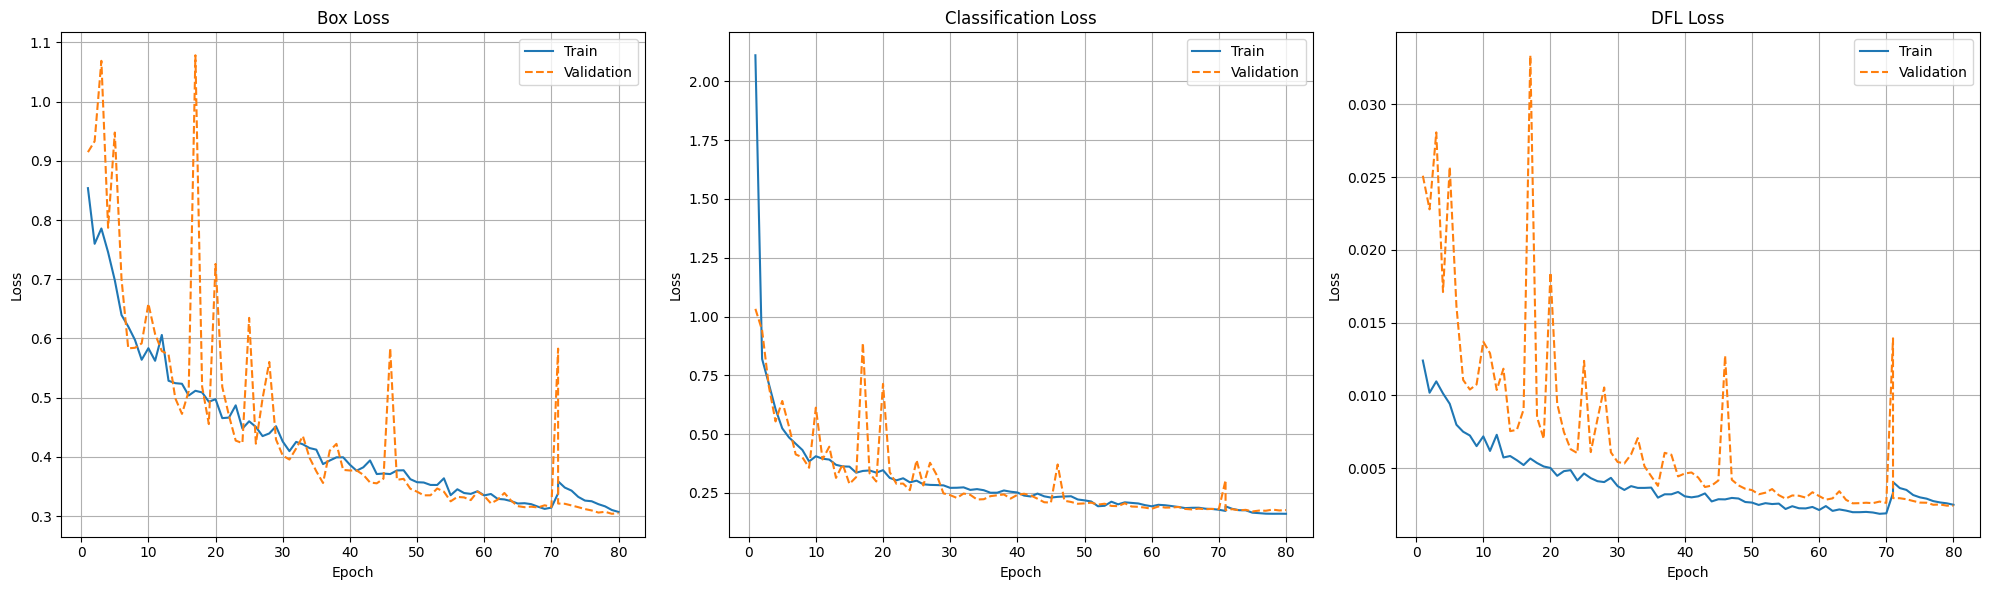

In [ ]:
# STEP 6: COMPREHENSIVE TRAINING VS VALIDATION LOSS ANALYSIS
#
# OBJECTIVE: Evaluate bounding box alignment and category grouping losses.
# WHY WE DO THIS: Visualizing validation vs training paths determines if the model
# is generalizing or falling victim to overfitting.


if metrics:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    # Box Loss
    axes[0].plot(df['epoch'], df['train/box_loss'], label='Train')
    axes[0].plot(df['epoch'], df['val/box_loss'], '--', label='Validation')
    axes[0].set_title('Box Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True)
    axes[0].legend()

    # Classification Loss
    axes[1].plot(df['epoch'], df['train/cls_loss'], label='Train')
    axes[1].plot(df['epoch'], df['val/cls_loss'], '--', label='Validation')
    axes[1].set_title('Classification Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True)
    axes[1].legend()

    # DFL Loss
    axes[2].plot(df['epoch'], df['train/dfl_loss'], label='Train')
    axes[2].plot(df['epoch'], df['val/dfl_loss'], '--', label='Validation')
    axes[2].set_title('DFL Loss')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Loss')
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.show()


Plotting training performance metrics dashboard...


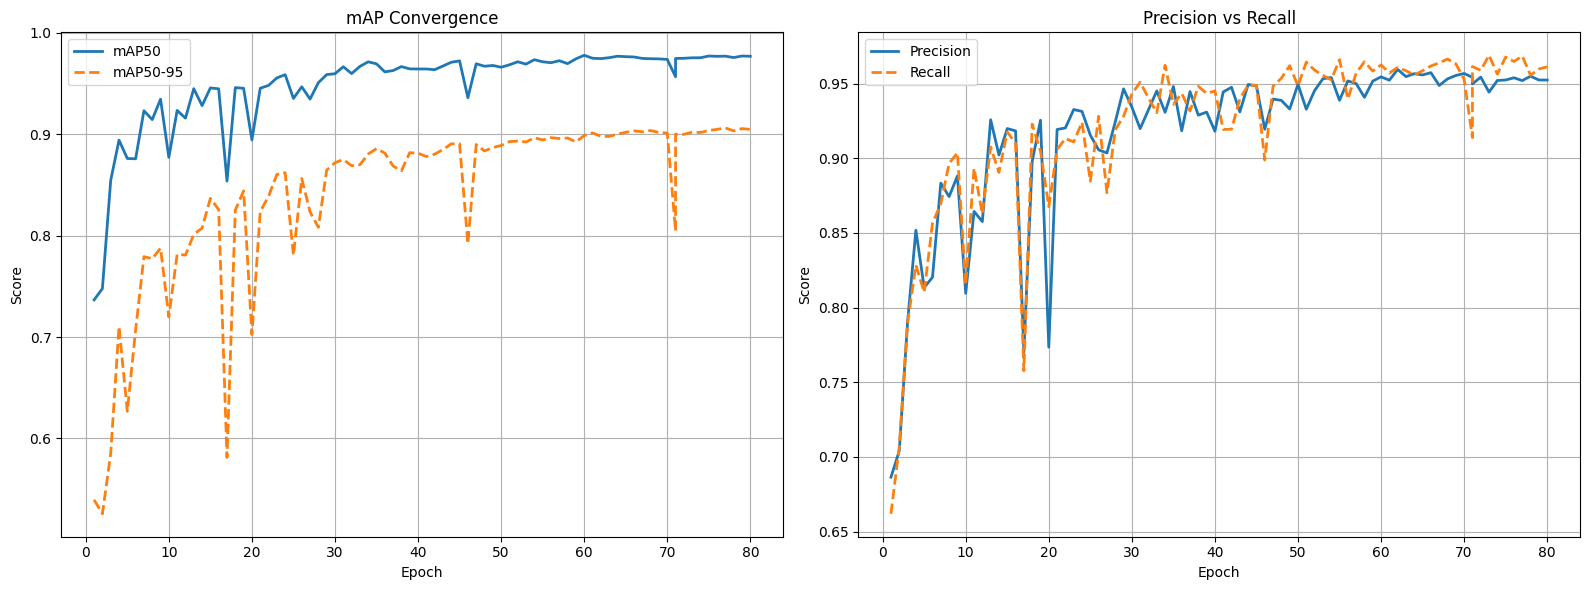

In [ ]:

# STEP 7: ADVANCED ACCURACY & PERFORMANCE METRICS PLOTTING
#
# OBJECTIVE: Analyze mean Average Precision and structural retrieval curves.
# WHY WE DO THIS: This proves exactly how reliably your model localizes layouts
# and whether it favors cautious exactness (Precision) or coverage (Recall).

if metrics:

    print("\nPlotting training performance metrics dashboard...")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- mAP Curves ---
    axes[0].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50', lw=2)
    axes[0].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95', lw=2, linestyle='--')
    axes[0].set_title('mAP Convergence')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Score')
    axes[0].grid(True)
    axes[0].legend()

    # --- Precision vs Recall ---
    axes[1].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', lw=2)
    axes[1].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', lw=2, linestyle='--')
    axes[1].set_title('Precision vs Recall')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Score')
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

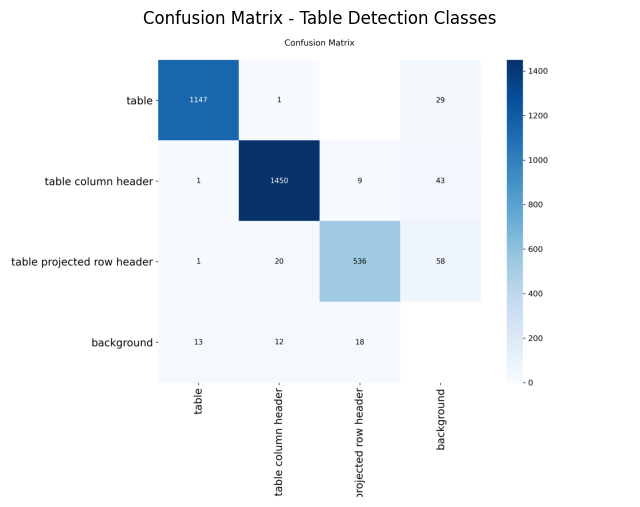

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

cm_path = os.path.join(RUN_DIR, "confusion_matrix.png")

img = cv2.imread(cm_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.title("Confusion Matrix - Table Detection Classes")
plt.axis("off")
plt.show()

In [ ]:
# STEP 8:  MODEL READINESS ANALYSIS
#
# OBJECTIVE: Run structural math validations against deployment benchmarks.
# WHY WE DO THIS: Automating threshold evaluations removes human guesswork,
# establishing a reliable go/no-go quality gate for the test set.

if metrics:
    print("\n" + "="*80)
    print(" EXECUTING AUTOMATED MODEL READINESS AUDIT")
    print("="*80)

    # Calculate absolute training error variance gaps
    latest = df.iloc[-1]
    box_gap = abs(latest['val/box_loss'] - latest['train/box_loss'])
    cls_gap = abs(latest['val/cls_loss'] - latest['train/cls_loss'])
    map50 = latest['metrics/mAP50(B)']
    map5095 = latest['metrics/mAP50-95(B)']

    # Display operational performance scores
    print(f"[1] STABILITY GAPS  -> Box Delta: {box_gap:.4f} | Class Delta: {cls_gap:.4f}")
    print(f"[2] ACCURACY SCORES -> mAP50: {map50:.4f} | mAP50-95: {map5095:.4f}")
    print(f"[3] PROFILE BALANCE -> Precision: {latest['metrics/precision(B)']:.4f} | Recall: {latest['metrics/recall(B)']:.4f}")

    # Track historical peaks to locate optimal weight checkpoints
    best_idx = df['metrics/mAP50-95(B)'].idxmax()
    print(f"[4] BEST PEAK   -> Best Epoch: #{int(df.loc[best_idx, 'epoch'])} (mAP50-95: {df.loc[best_idx, 'metrics/mAP50-95(B)']:.4f})")



    # Per class performance summery
    print("\n" + "="*80)
    print("                      PER-CLASS PERFORMANCE SUMMARY")
    print("="*80)
    print(f"{'CLASS (Row Header)':<20} | {'PRECISION':>12} | {'RECALL':>12} | {'mAP@0.50':>12} | {'mAP@0.50:0.95':>14}")
    print("-"*80)

    # 2. Populate Rows dynamically from your metrics object
    for i, name in metrics.names.items():
        # Retrieve values for the current class index
        precision = metrics.box.p[i]
        recall = metrics.box.r[i]
        ap50 = metrics.box.ap50[i]
        ap50_95 = metrics.box.maps[i]

        # Print formatted row matching the headers perfectly
        print(f"{name:<20} | {precision:>12.4f} | {recall:>12.4f} | {ap50:>12.4f} | {ap50_95:>14.4f}")


    print("="*80)
    if (map50 >= 0.90 and map5095 >= 0.75 and box_gap < 0.20 and cls_gap < 0.20):
        print("  PASSED. MODEL READY FOR TEST SET EVALUATION.")
    else:
        print("FAILED. REVIEW SYSTEM LOGS BEFORE RUNNING TEST SET.")



 EXECUTING AUTOMATED MODEL READINESS AUDIT
[1] STABILITY GAPS  -> Box Delta: 0.0021 | Class Delta: 0.0159
[2] ACCURACY SCORES -> mAP50: 0.9768 | mAP50-95: 0.9046
[3] PROFILE BALANCE -> Precision: 0.9524 | Recall: 0.9612
[4] BEST PEAK   -> Best Epoch: #77 (mAP50-95: 0.9061)

                      PER-CLASS PERFORMANCE SUMMARY
CLASS (Row Header)   |    PRECISION |       RECALL |     mAP@0.50 |  mAP@0.50:0.95
--------------------------------------------------------------------------------
table                |       0.9808 |       0.9854 |       0.9935 |         0.9888
table column header  |       0.9724 |       0.9727 |       0.9875 |         0.9191
table projected row header |       0.9033 |       0.9485 |       0.9498 |         0.8113
  PASSED. MODEL READY FOR TEST SET EVALUATION.


#Testing

In [ ]:
# CELL 1: TEST DATASET CACHING & TOPOLOGY DIAGNOSTICS
#
# OBJECTIVE: Move the test dataset split and configuration from Google Drive to local disk.
# WHY WE DO THIS: Eliminates drive latency during holdout evaluation and ensures
# the file path topology matches your dataset configuration requirements.
#
# WHAT THIS CELL DOES IN SIMPLE TERMS:
# This cell clears out any old data from your local Colab storage and copies a
# fresh copy of your 'test' images/labels and your 'dataset.yaml' file from
# Google Drive. This sets up a high-speed local environment for testing.

import os
import shutil

# --- 1. SET PATHS ---
drive_path = "/content/drive/MyDrive/table_dataset"
local_path = "/content/table_dataset"

test_source = os.path.join(drive_path, 'test')
test_dest = os.path.join(local_path, 'test')

yaml_source = os.path.join(drive_path, "dataset.yaml")
yaml_dest = os.path.join(local_path, "dataset.yaml")

print("\n" + "="*80)
print(" CACHING HOLDOUT TEST DATASET & CONFIGURATION TO LOCAL STORAGE")
print("="*80)

# --- 2. CLEAN UP OLD CACHE ---
if os.path.exists(local_path):
    print(" Cleaning up old local workspace copy...")
    shutil.rmtree(local_path)

os.makedirs(local_path, exist_ok=True)

# --- 3. COPY TEST DATASET SPLIT ---
if os.path.exists(test_source):
    print(" Copying test split matrix: test/ ...")
    shutil.copytree(test_source, test_dest)
    print("  └── Cache allocation for test split completed successfully!")
else:
    print(" WARNING: Required split folder 'test' missing from source path!")

# --- 4. COPY DATA CONFIGURATION (YAML) ---
if os.path.exists(yaml_source):
    print(" Copying dataset.yaml configuration file...")
    shutil.copyfile(yaml_source, yaml_dest)
    print("  └── Dataset configuration file cached successfully!")
else:
    print(" WARNING: dataset.yaml not found at source path!")

# --- 5. VERIFY HOLDOUT TOPOLOGY ---
print("\n" + "="*80)
print(" DATASET TOPOLOGY VERIFICATION (POST-TEST INGESTION)")
print("="*80)
print("• Root Contents:", os.listdir(local_path))

if os.path.exists(test_dest):
    print("• Content inside test/ :", os.listdir(test_dest)[:3], "... (truncated)")
else:
    print("• Content inside test/ : Missing Split Folder")
print("="*80)

# --- 6. PRINT DATASET.YAML CONTENTS ---
print("\n" + "="*80)
print(" VERIFYING DATASET.YAML CONFIGURATION PATHS")
print("="*80)
if os.path.exists(yaml_dest):
    with open(yaml_dest, 'r', encoding='utf-8') as f:
        print(f.read())
else:
    print(" ERROR: dataset.yaml is missing from local path layout!")
print("="*80)


 CACHING HOLDOUT TEST DATASET & CONFIGURATION TO LOCAL STORAGE
 Copying test split matrix: test/ ...
  └── Cache allocation for test split completed successfully!
 Copying dataset.yaml configuration file...
  └── Dataset configuration file cached successfully!

 DATASET TOPOLOGY VERIFICATION (POST-TEST INGESTION)
• Root Contents: ['test', 'dataset.yaml']
• Content inside test/ : ['labels', 'images', 'labels.cache'] ... (truncated)

 VERIFYING DATASET.YAML CONFIGURATION PATHS
names:
  0: table
  1: table column header
  2: table projected row header
path: /content/drive/MyDrive/table_dataset
test: test/images
train: train/images
val: val/images



In [ ]:
# CELL 2: MODEL TESTING & EVALUATION EXECUTOR
#
# OBJECTIVE: Execute validation math against the unseen local test split.
# WHY WE DO THIS: Providing a definitive, holdout-set benchmark confirms
# real-world generalization before production deployment.
#
# WHAT THIS CELL DOES
# This cell loads your best-trained model weights from Google Drive and tests
# them on a completely unseen "holdout test set." It grades how well your model
# can detect objects in the real world by calculating final accuracy scores and
# saving visual performance plots.

from ultralytics import YOLO

# --- CONFIGURATION AND PATHS ---
yaml_path = "/content/table_dataset/dataset.yaml"
best_weights = "/content/drive/MyDrive/YOLOv26_TableProject/table_detectorm/weights/best.pt"

# Load the best weight checkpoint from Drive
model = YOLO(best_weights)

# Run holdout validation with your exact hyperparameters
test_metrics = model.val(
    data=yaml_path,      # Path to the dataset configuration file (.yaml)
    split="test",        # Forces evaluation on the holdout test set instead of validation set
    conf=0.5,           # Confidence threshold: ignores any detections with a score below 25%
    iou=0.75,             # Intersection over Union threshold for Non-Maximum Suppression (NMS)
    imgsz=800,           # Resizes network input images to 640x640 pixels for consistent inference
    save=True,           # Saves visualized prediction images showing bounding boxes to disk
    plots=True,          # Generates and saves evaluation graphics (Confusion Matrix, PR curves, etc.)
    verbose=False        # Silences the default frame-by-frame terminal printing to keep logs clean
)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,351,765 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 261.8±192.4 MB/s, size: 930.5 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1q3sT7aG7rrxMLIKF2fYWnyX7q7UBLZE3/table_dataset/test/labels.cache... 493 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 493/493 121.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 1.3s/it 41.6s
                   all        493       1631      0.977      0.954      0.954      0.891
Speed: 3.0ms preprocess, 34.3ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/runs/detect/val-2


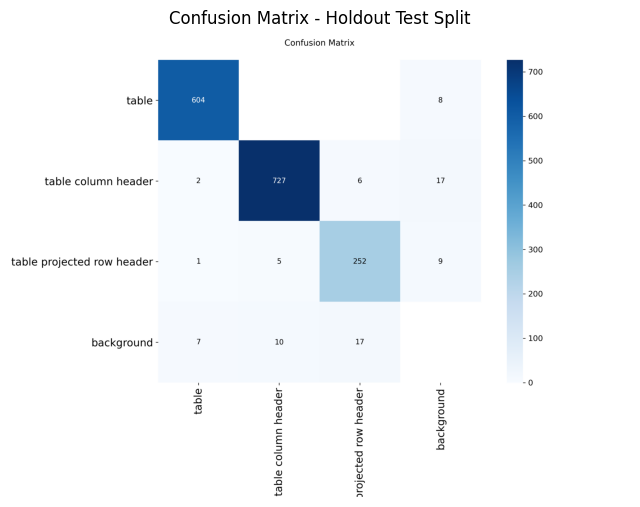

In [ ]:
# STEP 6.5: HOLDOUT TEST SET CONFUSION MATRIX DISPLAY
#
# OBJECTIVE: Visualize classification breakdowns and background false positives.
# WHY WE DO THIS: Evaluating the holdout confusion matrix isolates true target
# intersections from background noise or misclassifications on totally unseen data.

import os
import cv2
import matplotlib.pyplot as plt

# Identify the saved test artifacts path dynamically from your test execution
cm_path = os.path.join(test_metrics.save_dir, "confusion_matrix.png")

if os.path.exists(cm_path):
    img = cv2.imread(cm_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title("Confusion Matrix - Holdout Test Split")
    plt.axis("off")
    plt.show()
else:
    print(f"Notice: Confusion matrix image not found at {cm_path}. Make sure plots=True was used.")

In [ ]:
# STEP 8: HOLDOUT TEST SET MODEL READINESS ANALYSIS
#
# OBJECTIVE: Run structural math validations against test benchmarks.
# WHY WE DO THIS: Automating threshold evaluations removes human guesswork,
# establishing a reliable quality gate before production deployment.

# 1. Extract Global Performance Benchmarks from Test Environment
test_map50 = test_metrics.box.map50
test_map5095 = test_metrics.box.map
test_precision = test_metrics.box.mp
test_recall = test_metrics.box.mr

print("\n" + "="*80)
print(" EXECUTING AUTOMATED HOLDOUT TEST SET AUDIT")
print("="*80)

# Display final test score profiles
print(f"[1] ACCURACY SCORES -> Test mAP50: {test_map50:.4f} | Test mAP50-95: {test_map5095:.4f}")
print(f"[2] PROFILE BALANCE -> Test Precision: {test_precision:.4f} | Test Recall: {test_recall:.4f}")
print(f"[3] LOG PATHS       -> Output Visual Logs: {test_metrics.save_dir}")

# 2. Per-Class Performance Table Configuration
print("\n" + "="*80)
print("                      FINAL PER-CLASS TEST SUMMARY")
print("="*80)
print(f"{'CLASS (Row Header)':<20} | {'PRECISION':>12} | {'RECALL':>12} | {'mAP@0.50':>12} | {'mAP@0.50:0.95':>14}")
print("-"*80)

# Populate rows dynamically from your test metrics object
for i, name in test_metrics.names.items():
    precision = test_metrics.box.p[i]
    recall = test_metrics.box.r[i]
    ap50 = test_metrics.box.ap50[i]
    ap50_95 = test_metrics.box.maps[i]

    print(f"{name:<20} | {precision:>12.4f} | {recall:>12.4f} | {ap50:>12.4f} | {ap50_95:>14.4f}")

print("="*80)

# 3. Quality Assurance Verdict Floor Check
if (test_map50 >= 0.90 and test_map5095 >= 0.75):
    print("  PASSED. MODEL MEETS PRODUCTION REQUIREMENTS FOR DEPLOYMENT.")
else:
    print("  FAILED. TEST SET SCORES DID NOT PASS DEPLOYMENT THRESHOLDS.")
print("="*80)


 EXECUTING AUTOMATED HOLDOUT TEST SET AUDIT
[1] ACCURACY SCORES -> Test mAP50: 0.9538 | Test mAP50-95: 0.8906
[2] PROFILE BALANCE -> Test Precision: 0.9769 | Test Recall: 0.9535
[3] LOG PATHS       -> Output Visual Logs: /content/runs/detect/val-2

                      FINAL PER-CLASS TEST SUMMARY
CLASS (Row Header)   |    PRECISION |       RECALL |     mAP@0.50 |  mAP@0.50:0.95
--------------------------------------------------------------------------------
table                |       0.9917 |       0.9821 |       0.9843 |         0.9755
table column header  |       0.9739 |       0.9717 |       0.9666 |         0.9062
table projected row header |       0.9652 |       0.9067 |       0.9106 |         0.7901
  PASSED. MODEL MEETS PRODUCTION REQUIREMENTS FOR DEPLOYMENT.


In [ ]:
# 2. Extract and sample random images from the test cache
import random

test_images_dir = "/content/table_dataset/test/images"
all_test_images = [img for img in os.listdir(test_images_dir) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
num_samples = min(10, len(all_test_images))  # Choose 3 images to display
random_samples = random.sample(all_test_images, num_samples)

# 3. Initialize Model
model = YOLO(best_weights)

print(f"Displaying predictions for {num_samples} random images from the holdout test set...\n")

# 4. Predict and Render Each Image
for img_name in random_samples:
    img_path = os.path.join(test_images_dir, img_name)

    # Run prediction with your exact threshold specs
    results = model.predict(source=img_path, conf=0.25, iou=0.6, imgsz=640, verbose=False)

    for result in results:
        # result.plot() automatically embeds the bounding box lines, labels, and confidence values
        annotated_img = result.plot()

        # Display inline inside your Colab notebook
        plt.figure(figsize=(10, 8))
        plt.imshow(annotated_img)
        plt.title(f"Random Test Sample: {img_name}")
        plt.axis("off")
        plt.show()